# Enzyme fitness landscape analysis

In this tutorial, we’ll use GraphFLA to explore how mutations in a gene shape bacterial fitness under antibiotic treatment. To see how this works, we’ll build and analyse a nucleotide landscape of the enzyme dihydrofolate reductase (DHFR), then measure its ruggedness, epistasis and navigability.


## 1. Setting up

On Google Colab, the cell below installs GraphFLA. In any environment, it also downloads the dataset into a `data/` folder next to the notebook if the files are not already there.

We then import GraphFLA for landscape construction and analysis, pandas for working with the data, and NumPy and Matplotlib for plotting interactions.

In [1]:
import sys
from pathlib import Path
from urllib.request import urlretrieve

if "google.colab" in sys.modules:
    %pip install -q graphfla==0.4.0

DATA_URL = "https://raw.githubusercontent.com/COLA-Laboratory/GraphFLA/v0.4.0/tutorials/datasets/data/"
Path("data").mkdir(exist_ok=True)
for name in ["dhfr.csv"]:
    if not Path("data", name).exists():
        urlretrieve(DATA_URL + name, Path("data", name))

In [2]:
from graphfla import analysis
from graphfla.landscape import DNALandscape
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


## 2. Loading the dataset

DHFR is an essential metabolic enzyme and the target of the antibiotic trimethoprim. [Papkou et al. (2023)](https://doi.org/10.1126/science.adh3860) used genome editing in *Escherichia coli* to create all combinations of the nine nucleotides encoding three adjacent amino acids, **A26, D27 and L28**. This gives **4⁹ = 262,144 genotypes**, of which the authors’ archived table contains **261,333** with measured fitness in the presence of trimethoprim.

We’ll maximise this fitness. On the authors’ scale, the wild type `GCCGATCTC` has fitness 0, and higher values mean better growth under the antibiotic.

| Column | Meaning |
|---|---|
| `sequence` | Nucleotides at the nine positions, codons 26, 27 and 28 in order. |
| `fitness` | Fitness relative to the wild type. |

Let’s load the measurements:


In [3]:
df = pd.read_csv("data/dhfr.csv", float_precision="round_trip")
df.head()


,sequence,fitness
0,GCCGATCTC,0.000000
1,AAAAAAAAA,-0.733843
2,AAAAAAAAC,-0.656973
3,AAAAAAAAG,-0.701521
4,AAAAAAAAT,-0.708582


## 3. Preparing the inputs

To construct a landscape, GraphFLA needs two aligned inputs:

- `X`: one row per configuration and one column per variable.
- `f`: one measured or calculated outcome for each row of `X`.

The nucleotide sequence forms `X`, and fitness forms `f`. `DNALandscape` reads each sequence string as nine positions with the alphabet A, C, G and T.

In [4]:
X = df["sequence"]
f = df["fitness"]
X.head()


0    GCCGATCTC
1    AAAAAAAAA
2    AAAAAAAAC
3    AAAAAAAAG
4    AAAAAAAAT
Name: sequence, dtype: object

## 4. Constructing the landscape

We can use `DNALandscape`, where neighbouring genotypes differ by a single nucleotide substitution. We set `maximize=True` because higher fitness is better.

Papkou et al. classified genotypes with fitness below −0.508 as nonfunctional and removed mutational steps between two nonfunctional genotypes before analysing the largest connected network. Setting `tau=-0.507774` with `filter_mode="both"` applies the same rule. With `epsilon=0`, any fitness difference counts as an improving move, as in the original analysis.


In [5]:
landscape = DNALandscape(maximize=True)
landscape.build_from_data(
    X, f, tau=-0.507774, filter_mode="both", epsilon=0, verbose=False,
)


DNALandscape(maximize=True)

## 5. Inspecting the landscape

Let’s first look at what we’ve built. Printing the landscape shows its variables, configurations, improving edges and local optima:


In [6]:
print(landscape)


DNALandscape(kind='dna'): 9 variables, 135178 configurations, 324044 edges, 514 local optima


The network keeps 135,178 genotypes, matching the network analysed by Papkou et al. For a closer look at individual genotypes, we can call `get_data()`. The nine nucleotides appear as `pos_0` to `pos_8`; `out_degree` counts directly improving moves, and `is_lo` indicates local-optimum membership.


In [7]:
landscape.get_data().head()


,pos_0,pos_1,pos_2,pos_3,pos_4,pos_5,pos_6,pos_7,pos_8,fitness,in_degree,out_degree,is_lo
0,G,C,C,G,A,T,C,T,C,0.000000,12,8,False
1,A,A,A,A,A,A,A,A,A,-0.733843,0,1,False
2,A,A,A,A,A,A,A,A,C,-0.656973,0,1,False
3,A,A,A,A,A,A,A,A,G,-0.701521,0,1,False
4,A,A,A,A,A,A,A,A,T,-0.708582,0,1,False


We can also summarise the fitness values with pandas:


In [8]:
landscape.get_data()["fitness"].describe()


count    135178.000000
mean         -0.585424
std           0.389963
min          -1.174803
25%          -0.750818
50%          -0.701699
75%          -0.639704
max           1.395792
Name: fitness, dtype: float64

Most genotypes in the network are nonfunctional, with fitness below −0.508. To inspect the fittest genotype, we can use the global-optimum node index:


In [9]:
landscape[landscape.go_index]


{'pos_0': 'A',
 'pos_1': 'A',
 'pos_2': 'G',
 'pos_3': 'G',
 'pos_4': 'A',
 'pos_5': 'A',
 'pos_6': 'A',
 'pos_7': 'T',
 'pos_8': 'G',
 'fitness': np.float64(1.395791684395264),
 'in_degree': 27,
 'out_degree': 0,
 'is_lo': True}

## 6. Analysing the landscape

Next, we’ll follow three questions in turn: how rugged the landscape is (6.1–6.2), which kinds of epistasis make it so (6.3–6.6), and whether evolution can still reach the best variant (6.7–6.8).


### 6.1 Number of local optima

We can start with `landscape.n_lo`. A local optimum, or fitness peak, is a variant without a fitter single-mutant neighbour; each connected neutral plateau of peaks counts once. Many peaks mean that adaptive walks, which accept only fitness-increasing mutations, can end at different variants.


In [10]:
print(f"Number of local optima: {landscape.n_lo}")


Number of local optima: 514


This reproduces the 514 fitness peaks reported by Papkou et al. We can also count the peaks that are fitter than the wild type:


In [11]:
peaks = landscape.get_data(lo_only=True)
print(f"Peaks fitter than the wild type: {(peaks['fitness'] > 0).sum()}")


Peaks fitter than the wild type: 106


### 6.2 Roughness-to-slope ratio

The peak count shows that the landscape is rugged, but not how far it departs from the simplest case. If every mutation had the same effect in every background, fitness would be additive and the landscape would have a single peak. The roughness-to-slope ratio, introduced by [Aita et al. (2000)](https://doi.org/10.1002/(SICI)1097-0282(200007)54:1%3C64::AID-BIP70%3E3.0.CO;2-R), measures this departure: it fits an additive model and compares the scatter left unexplained with the average size of the mutation effects. Values near zero indicate a nearly additive landscape; larger values indicate a more rugged one.

`r_s_ratio()` encodes each position relative to a reference nucleotide, so we compare values only when they are calculated in the same way.


In [12]:
roughness_to_slope = analysis.r_s_ratio(landscape)
print(f"Roughness-to-slope ratio: {roughness_to_slope:.4f}")


Roughness-to-slope ratio: 3.3562


### 6.3 Gamma star

Not every departure from additivity creates peaks. A mutation that is beneficial in every background still leads uphill; multiple peaks can arise only when mutation effects reverse direction between backgrounds, known as sign epistasis. [Ferretti et al. (2016)](https://doi.org/10.1016/j.jtbi.2016.01.037) proposed measuring epistasis by how well a mutation’s effect carries over when a second mutation is added to the background. `gamma_star()` applies this idea to the direction of effects only; we run it in a single process (`n_jobs=1`), which is fast enough here.

A value of 1 means mutations never switch between beneficial and deleterious; values near zero indicate frequent switches, and negative values indicate that pairs of mutations often reverse each other’s direction (reciprocal sign epistasis).


In [13]:
sign_correlation = analysis.gamma_star(landscape, n_jobs=1)
print(f"Gamma star: {sign_correlation:.4f}")


Gamma star: 0.1417


### 6.4 Idiosyncratic epistasis

Gamma star records only whether effects change direction. Even when the direction holds, the size of an effect can change from one background to another. [Lyons et al. (2020)](https://doi.org/10.1038/s41559-020-01286-y) introduced the idiosyncratic index to measure this variation: it compares the spread of a mutation’s effects across backgrounds with the fitness differences between randomly paired variants. A value of zero means each mutation has the same effect everywhere; a value near one means its effect varies about as much as the difference between two random variants.

`global_idiosyncratic_index()` averages this index over all mutations. Random pairs are drawn with a fixed seed.


In [14]:
idiosyncrasy = analysis.global_idiosyncratic_index(landscape, seed=42, n_jobs=1)
print(f"Global idiosyncratic index: {idiosyncrasy:.4f}")


Global idiosyncratic index: 0.4593


### 6.5 Walsh–Hadamard decomposition

Gamma star and the idiosyncratic index summarise epistasis across the whole landscape, but they do not show which positions are responsible. `walsh_hadamard()` helps locate it by describing fitness as a sum of single-mutation effects and interactions between pairs of positions, using the multistate extension of [Faure et al. (2024)](https://doi.org/10.1371/journal.pcbi.1012132). We stop at pairs, leaving higher-order interactions unresolved.

The pairwise model has 352 coefficients, fitted to all 135,178 genotypes by ordinary least squares. Its design matrix has about 48 million entries, above the default `max_cells` safeguard of 10 million, so we raise that limit explicitly. Compare the first- and second-order training `r2`; `delta_r2` shows the extra variation explained by pairwise terms.


In [15]:
wh = analysis.walsh_hadamard(landscape, max_order=2, max_cells=5e7)
wh["order_summary"]


,order,r2,delta_r2,rmse,n_terms,rank,alpha,model_variance_fraction,n_nonzero
0,0,0.000000,0.000000,0.389962,1,1,NaN,0.000000,<NA>
1,1,0.356538,0.356538,0.312812,28,28,NaN,0.294879,<NA>
2,2,0.758929,0.402391,0.191467,352,352,NaN,0.705121,<NA>


Which positions carry this variation? The helper functions below split the fitted model’s variance, taken over all possible combinations of nucleotides, into a share for each position (diagonal) and for each pair of positions (off-diagonal). The diagonal holds the additive part and the off-diagonal cells the pairwise part; each pair appears twice, and the diagonal plus one triangle add up to 100%. Unlike individual coefficients, these shares do not depend on the reference nucleotide. Positions are labelled by codon and by place within the codon.

As a check, the pairwise shares add up to the order-2 `model_variance_fraction` in the table above.


In [16]:
def term_variance(block):
    """Variance of one fitted term over all allele combinations."""
    alleles = [
        part.str.extract(r"^(?P<ref>\w)_\d+_(?P<alt>\w)$")
        for _, part in block["term"].str.split("-", expand=True).items()
    ]
    states = [sorted({a["ref"].iloc[0], *a["alt"]}) for a in alleles]
    # Reference alleles keep a zero coefficient.
    effects = np.zeros([len(s) for s in states])
    for k, coefficient in enumerate(block["coefficient"]):
        cell = tuple(s.index(a["alt"].iloc[k]) for s, a in zip(states, alleles))
        effects[cell] = coefficient
    for axis in range(effects.ndim):
        effects = effects - effects.mean(axis=axis, keepdims=True)
    return np.mean(effects**2)


def variance_shares(coefficients, n_positions):
    """Share of fitted variance from each position (diagonal) and pair."""
    shares = np.zeros((n_positions, n_positions))
    for positions, block in coefficients.query("order > 0").groupby("positions"):
        i, j = positions[0] - 1, positions[-1] - 1
        shares[i, j] = shares[j, i] = term_variance(block)
    return shares / (np.trace(shares) + np.triu(shares, 1).sum())


def plot_shares(shares, labels):
    n = len(labels)
    size = min(0.55 * n, 6.0)
    percent = 100 * shares
    fig, ax = plt.subplots(figsize=(size + 2.4, size + 1.6))
    image = ax.imshow(percent, cmap="viridis")
    ax.set_xticks(range(n), labels, rotation=90 if n > 6 else 0)
    ax.set_yticks(range(n), labels)
    if n <= 9:
        midpoint = percent.max() / 2
        for (i, j), value in np.ndenumerate(percent):
            color = "black" if value > midpoint else "white"
            ax.text(j, i, f"{value:.1f}", ha="center", va="center",
                    fontsize=8, color=color)
    fig.colorbar(image, ax=ax, label="Share of fitted variance (%)")
    fig.tight_layout()
    plt.show()


Pairwise share of fitted variance: 0.705


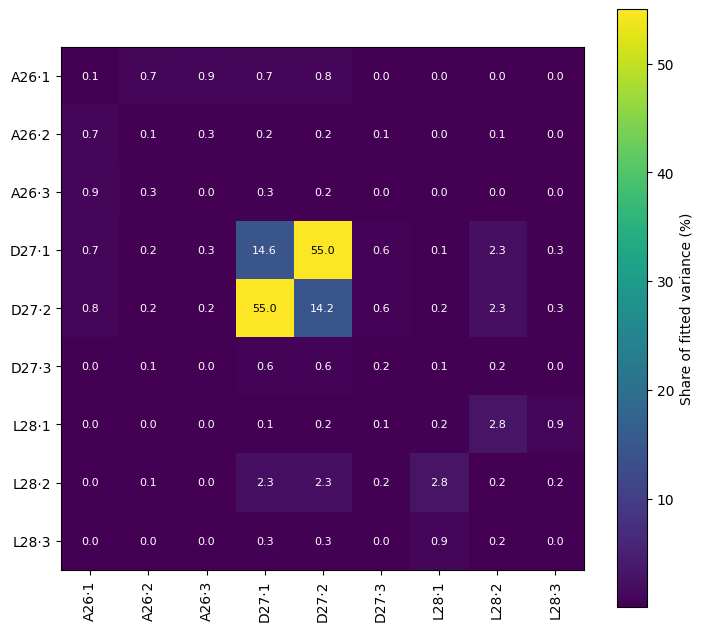

In [17]:
labels = ["A26·1", "A26·2", "A26·3", "D27·1", "D27·2", "D27·3", "L28·1", "L28·2", "L28·3"]
shares = variance_shares(wh["coefficients"], n_positions=9)
print(f"Pairwise share of fitted variance: {np.triu(shares, 1).sum():.3f}")
plot_shares(shares, labels)


### 6.6 Diminishing returns and increasing costs

Interactions between particular positions are one source of background dependence. Another is a general trend with how fit the background already is, known as global epistasis. Beneficial mutations can help less in fitter backgrounds, known as diminishing returns ([Chou et al., 2011](https://doi.org/10.1126/science.1203799)), while deleterious mutations can cost more, known as increasing costs ([Johnson et al., 2019](https://doi.org/10.1126/science.aay4199)).

`diminishing_returns_index()` correlates background fitness with the gain of each beneficial mutation; a negative value indicates diminishing returns. `increasing_costs_index()` correlates background fitness with the loss of each deleterious mutation; a positive value indicates increasing costs. Both pool all mutations together and depend on the fitness scale.


In [18]:
returns = analysis.diminishing_returns_index(landscape)
costs = analysis.increasing_costs_index(landscape)
print(f"Diminishing returns index: {returns:.4f}")
print(f"Increasing costs index: {costs:.4f}")


Diminishing returns index: -0.4765
Increasing costs index: 0.4411


### 6.7 Global optimum accessibility

Ruggedness and epistasis matter for evolution because peaks can trap adaptive walks. `global_optima_accessibility()` asks whether the fittest variant can still be reached: it returns the fraction of variants from which some path of fitness-increasing single mutations leads to the global optimum. A value of 1 means every variant has such a path; a small value means most adaptive walks must end at other peaks.


In [19]:
accessibility = analysis.global_optima_accessibility(landscape)
print(f"Global optimum accessibility: {accessibility:.4f}")


Global optimum accessibility: 0.7235


### 6.8 Fitness-distance correlation

Accessibility tells us whether an uphill path to the global optimum exists, not whether fitness points towards it. [Jones and Forrest (1995)](https://fluidinfo.com/research/fdc-abs.html) introduced fitness-distance correlation for this question. `fdc()` correlates each variant’s fitness with its number of mutations from the global optimum. A negative value means fitter variants tend to lie closer to the best variant; a value near zero means distance tells us little about fitness.


In [20]:
fitness_distance_r = analysis.fdc(landscape, method="spearman")
print(f"Fitness-distance correlation: {fitness_distance_r:.4f}")


Fitness-distance correlation: -0.1397


In summary, the DHFR landscape is highly rugged, with 514 peaks and an r/s ratio of 3.36. Sign epistasis is frequent (γ* = 0.142), and pairwise terms account for 71% of the fitted variance. More than half of it, 55%, comes from a single pair: the first two nucleotides of codon 27, which together largely determine the encoded amino acid. Beneficial mutations gain less (−0.476) and deleterious mutations cost more (0.441) in fitter backgrounds. Despite this ruggedness, 72.4% of genotypes in the network have a fitness-increasing path to the global optimum, consistent with Papkou et al.’s conclusion that the highest peaks remain accessible through abundant paths.


## 7. Running several analyses together

We can collect the single-value metrics above with `analysis.profile()`, using the same seed for the idiosyncratic index. `landscape.n_lo` supplies the peak count directly; the W–H result keeps its separate coefficient and order-summary tables.


In [21]:
analysis.profile(
    landscape,
    metrics=[
        "r_s_ratio", "gamma_star", "global_idiosyncratic_index",
        "diminishing_returns_index", "increasing_costs_index",
        "global_optima_accessibility", "fdc",
    ],
    seed=42, n_jobs=1, progress=False,
)


r_s_ratio                      3.356195
gamma_star                     0.141657
global_idiosyncratic_index     0.459263
diminishing_returns_index     -0.476487
increasing_costs_index         0.441070
global_optima_accessibility    0.723520
fdc                           -0.139723
dtype: float64

## 8. Analysis reference

For further exploration, `analysis.list_metrics()` lists the metrics available to `profile()`. The worked W–H result also exposes `fit_info`; its order summary separates cumulative training fit from the fitted model’s variance spectrum.

### Data sources

Papkou A. et al. (2023). [A rugged yet easily navigable fitness landscape](https://doi.org/10.1126/science.adh3860). We use the unrounded fitness table `fitness_data_wt.rds` from the [authors’ archive](https://doi.org/10.5281/zenodo.8228920) (CC BY 4.0), with columns renamed to `sequence` and `fitness`. Its 261,333 genotypes differ from the 261,382 stated in the article.